In [2]:
# ============================================================
# RNN PROJECT SETUP (TEXT CLASSIFICATION PIPELINE)
# Imports, preprocessing tools, and model components setup
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from wordcloud import WordCloud

from collections import Counter

# ---------------- NLTK resources ----------------
nltk.download("stopwords", quiet=True)
nltk.download("wordnet", quiet=True)


True

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os
import zipfile

# ZIP file path
zip_file = "/content/drive/MyDrive/dataset/5. Movie Review Dataset-20260509T110927Z-3-001.zip"

# Extract location
extract_path = "/content/drive/MyDrive/dataset"

# Extract dataset
with zipfile.ZipFile(zip_file, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")



Dataset extracted successfully!


In [4]:

# LOAD MOVIE REVIEW DATASET
# Reads train/validation/test CSV files and checks structure


import pandas as pd

# ---------------- Dataset paths ----------------
train_path = "/content/drive/MyDrive/dataset/5. Movie Review Dataset/train_movie_review.csv"
val_path   = "/content/drive/MyDrive/dataset/5. Movie Review Dataset/val_movie_review.csv"
test_path  = "/content/drive/MyDrive/dataset/5. Movie Review Dataset/test_movie_review.csv"

# ---------------- Load data ----------------
train_df = pd.read_csv(train_path)
val_df   = pd.read_csv(val_path)
test_df  = pd.read_csv(test_path)

# ---------------- Basic info ----------------
print("Dataset Shapes:")
print(f"Train: {train_df.shape}")
print(f"Validation: {val_df.shape}")
print(f"Test: {test_df.shape}")

print("\nColumns in dataset:")
print(list(train_df.columns))

# preview
train_df.head()

Dataset Shapes:
Train: (35000, 3)
Validation: (5000, 3)
Test: (10000, 3)

Columns in dataset:
['Unnamed: 0', 'review', 'sentiment']


,Unnamed: 0,review,sentiment
0,3774,"Having avoided seeing the movie in the cinema,...",0
1,48396,With this movie I was really hoping that the i...,0
2,1980,Raymond Burr stars as an attorney caught up in...,0
3,6703,A lot people get hung up on this films tag as ...,1
4,28168,I was a fan of Buffy and hoped it would come t...,0


In [5]:

# CLEAN DATASET
# Removes unwanted index column and verifies text data format


# remove extra index column if it exists
for df in [train_df, val_df, test_df]:
    if "Unnamed: 0" in df.columns:
        df.drop(columns=["Unnamed: 0"], inplace=True)

# ---------------- Check structure ----------------
print("Cleaned Columns:")
print(list(train_df.columns))

# ---------------- Sample review ----------------
print("\nSample review text:\n")
print(train_df["review"].iloc[0][:200] + "...")

Cleaned Columns:
['review', 'sentiment']

Sample review text:

Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -...


Sentiment Distribution: Counter({0: 17584, 1: 17416})
Class balance ratio (Negative:Positive): 1.010


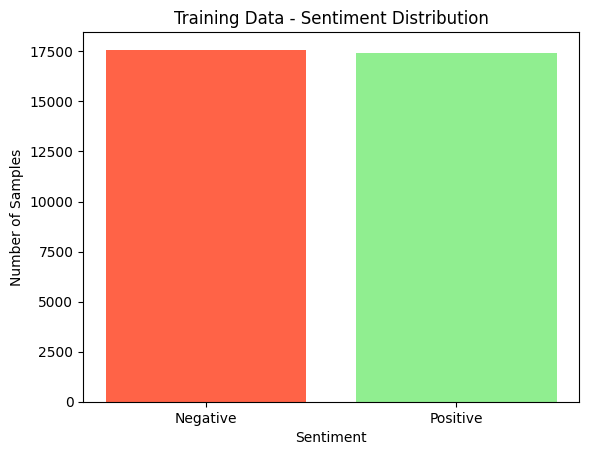

In [6]:
# Check sentiment distribution in training data and visualize class balance

from collections import Counter
import matplotlib.pyplot as plt

target_counts = Counter(train_df["sentiment"])

print("Sentiment Distribution:", target_counts)
print(f"Class balance ratio (Negative:Positive): {target_counts[0] / target_counts[1]:.3f}")

plt.bar(
    target_counts.keys(),
    target_counts.values(),
    color=["tomato", "lightgreen"]
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Samples")
plt.title("Training Data - Sentiment Distribution")
plt.xticks([0, 1], ["Negative", "Positive"])

plt.show()

In [7]:
# Define preprocessing tools for text cleaning (stopwords + lemmatization setup)

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

negations = {"not", "no", "nor", "never", "none", "neither"}

stop_words = set(stopwords.words("english")) - negations

lemmatizer = WordNetLemmatizer()

In [8]:
# Clean and preprocess movie reviews for RNN model training

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]+>', ' ', text)
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)

    contractions = {
        "don't": "do not", "doesn't": "does not", "didn't": "did not",
        "won't": "will not", "wouldn't": "would not", "shouldn't": "should not",
        "couldn't": "could not", "can't": "cannot", "isn't": "is not",
        "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "haven't": "have not", "hasn't": "has not", "i'm": "i am",
        "you're": "you are", "it's": "it is", "that's": "that is",
        "n't": " not"
    }

    for c, e in contractions.items():
        text = text.replace(c, e)

    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\d+', '', text)

    tokens = text.split()
    tokens = [lemmatizer.lemmatize(w) for w in tokens if w not in stop_words]

    return " ".join(tokens)

# test preprocessing
sample = train_df["review"].iloc[1]
cleaned = preprocess_text(sample)

print("Original:", sample[:200])
print("\nCleaned:", cleaned[:200])

Original: With this movie I was really hoping that the idea was to make up for the hashed together ineptitude of the first AVP, and yet to my horror: Requiem is far worse than I could have imagined.<br /><br />

Cleaned: movie really hoping idea make hashed together ineptitude first avp yet horror requiem far worse could imagined hope opening moment film inside predator ship almost breathed sigh relief finally saw pre


In [9]:
# Apply preprocessing function to train, validation, and test datasets

print("Cleaning training set...")
train_df["cleaned_text"] = train_df["review"].apply(preprocess_text)

print("Cleaning validation set...")
val_df["cleaned_text"] = val_df["review"].apply(preprocess_text)

print("Cleaning test set...")
test_df["cleaned_text"] = test_df["review"].apply(preprocess_text)

print("\nSample comparison:")
print("Original:", train_df["review"].iloc[0][:200])
print("Cleaned :", train_df["cleaned_text"].iloc[0][:200])

Cleaning training set...
Cleaning validation set...
Cleaning test set...

Sample comparison:
Original: Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -
Cleaned : avoided seeing movie cinema buying dvd wife xmas watch not expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical rac


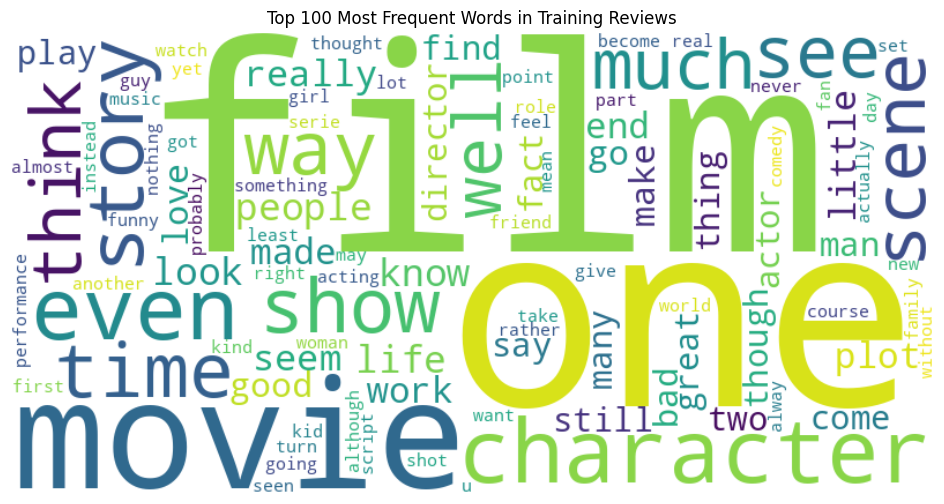

In [ ]:
# Generate word cloud to visualize most frequent words in cleaned training reviews

from wordcloud import WordCloud
import matplotlib.pyplot as plt

all_words = " ".join(train_df["cleaned_text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white",
    max_words=100
).generate(all_words)

plt.figure(figsize=(12, 6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in Training Reviews")
plt.show()

In [ ]:
# Demonstration of tokenizer behavior on sample sentences before training on full dataset

from tensorflow.keras.preprocessing.text import Tokenizer

sample_texts = [
    "I love this movie!",
    "Worst film ever.",
    "Happy with the experience.",
    "Not great, not terrible.",
    "Absolutely fantastic!"
]

demo_tokenizer = Tokenizer(num_words=10000, oov_token="<OOV>")
demo_tokenizer.fit_on_texts(sample_texts)

demo_sequences = demo_tokenizer.texts_to_sequences(sample_texts)

print("Word Index:")
print(demo_tokenizer.word_index)

print("\nSequences:")
print(demo_sequences)

Demo Word Index: {'<OOV>': 1, 'not': 2, 'i': 3, 'love': 4, 'this': 5, 'movie': 6, 'worst': 7, 'film': 8, 'ever': 9, 'happy': 10, 'with': 11, 'the': 12, 'experience': 13, 'great': 14, 'terrible': 15, 'absolutely': 16, 'fantastic': 17}
Demo Sequences : [[3, 4, 5, 6], [7, 8, 9], [10, 11, 12, 13], [2, 14, 2, 15], [16, 17]]


In [ ]:
# Build tokenizer on training data and convert text into integer sequences for RNN input

from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(num_words=20000, oov_token="<OOV>")
tokenizer.fit_on_texts(train_df["cleaned_text"])

X_train_seq = tokenizer.texts_to_sequences(train_df["cleaned_text"])
X_val_seq   = tokenizer.texts_to_sequences(val_df["cleaned_text"])
X_test_seq  = tokenizer.texts_to_sequences(test_df["cleaned_text"])

print("Vocabulary size:", len(tokenizer.word_index))
print("Sample review word count:", len(train_df["cleaned_text"].iloc[100].split()))

Vocabulary length (full)  : 122385
Example sequence length   : 40


In [ ]:
# Analyze sequence lengths and apply padding for RNN input preparation

from tensorflow.keras.preprocessing.sequence import pad_sequences
import numpy as np

seq_lengths = [len(seq) for seq in X_train_seq]

print(f"Max sequence length before padding: {max(seq_lengths)}")

print("\nSequence length statistics:")
print(f"Min    : {np.min(seq_lengths)}")
print(f"Max    : {np.max(seq_lengths)}")
print(f"Mean   : {np.mean(seq_lengths):.0f}")
print(f"Median : {np.median(seq_lengths):.0f}")
print(f"95th % : {np.percentile(seq_lengths, 95):.0f}")
print(f"99th % : {np.percentile(seq_lengths, 99):.0f}")

max_len = int(np.percentile(seq_lengths, 95))
print(f"\nSelected max_len: {max_len}")

X_train_pad = pad_sequences(X_train_seq, maxlen=max_len, padding="post", truncating="post")
X_val_pad   = pad_sequences(X_val_seq, maxlen=max_len, padding="post", truncating="post")
X_test_pad  = pad_sequences(X_test_seq, maxlen=max_len, padding="post", truncating="post")

y_train = np.array(train_df["sentiment"].values)
y_val   = np.array(val_df["sentiment"].values)
y_test  = np.array(test_df["sentiment"].values)

print("\nFinal shapes:")
print(f"X_train: {X_train_pad.shape}")
print(f"X_val  : {X_val_pad.shape}")
print(f"X_test : {X_test_pad.shape}")

Max sequence length before padding: 1420

Sequence length statistics:
  Min     : 4
  Max     : 1420
  Mean    : 117
  Median  : 87
  95th %  : 302
  99th %  : 458

Using max_len: 302

Final shapes:
  X_train_pad: (35000, 302)
  X_val_pad  : (5000, 302)
  X_test_pad : (10000, 302)


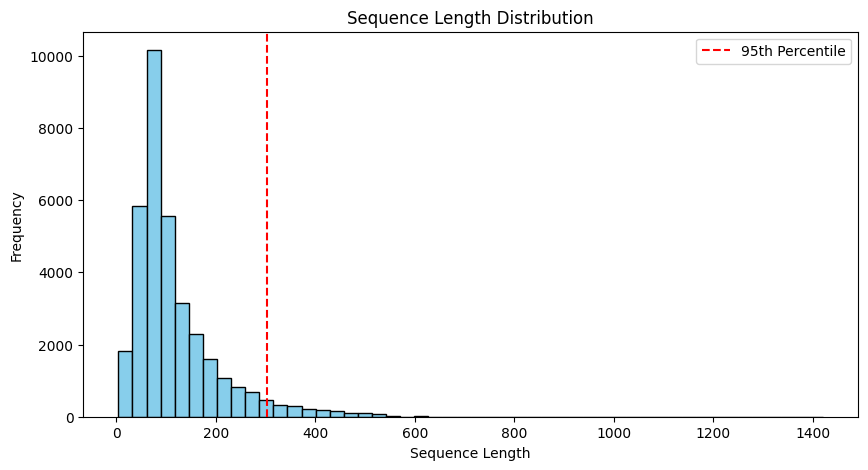

In [ ]:
# Visualize distribution of sequence lengths to decide optimal padding size

import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 5))

plt.hist(seq_lengths, bins=50, color="skyblue", edgecolor="black")

plt.title("Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")

p95 = np.percentile(seq_lengths, 95)
plt.axvline(p95, color="red", linestyle="dashed", label="95th Percentile")

plt.legend()
plt.show()

In [ ]:
# Check class balance across splits and compute OOV (out-of-vocabulary) rate

from collections import Counter
import numpy as np

train_counts = Counter(y_train)
val_counts   = Counter(y_val)
test_counts  = Counter(y_test)

print("Class distribution:")
print(f"Train → Negative: {train_counts[0]} | Positive: {train_counts[1]}")
print(f"Val   → Negative: {val_counts[0]} | Positive: {val_counts[1]}")
print(f"Test  → Negative: {test_counts[0]} | Positive: {test_counts[1]}")

oov_index = tokenizer.word_index.get("<OOV>", 1)

total_tokens = X_test_pad[X_test_pad != 0].size
oov_tokens   = (X_test_pad == oov_index).sum()

print("\nOOV analysis (Test set):")
print(f"OOV tokens: {oov_tokens}")
print(f"Total tokens: {total_tokens}")
print(f"OOV rate: {oov_tokens / total_tokens * 100:.2f}%")

── Class distribution ──
  Train → Neg: 17584  Pos: 17416
  Val   → Neg: 2455   Pos: 2545
  Test  → Neg: 4961  Pos: 5039

── OOV rate on Test Set: 5.5% (62744/1132718 tokens)


In [ ]:
# Build a Simple RNN model for binary sentiment classification

vocab_size = len(tokenizer.word_index) + 1
embedding_dim = 128
hidden_units = 64

print("Model: Simple RNN for Sentiment Classification")

model_rnn = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    SimpleRNN(hidden_units),
    Dense(1, activation="sigmoid")
])

model_rnn.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_rnn.summary()

MODEL 1: SimpleRNN model


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 302, 128)       │    15,665,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │        12,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,677,825 (59.81 MB)

 Trainable params: 15,677,825 (59.81 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Build an LSTM model for sentiment classification

print("Model: LSTM for Sentiment Classification")

model_lstm = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=embedding_dim),
    LSTM(hidden_units),
    Dense(1, activation="sigmoid")
])

model_lstm.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_lstm.summary()

MODEL 2: LSTM model


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 302, 128)       │    15,665,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,714,881 (59.95 MB)

 Trainable params: 15,714,881 (59.95 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train Simple RNN model with checkpointing and early stopping

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_rnn = ModelCheckpoint(
    "simple_rnn_best.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_rnn = model_rnn.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoint_rnn, early_stop]
)

Epoch 1/10
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.4952 - loss: 0.6967
Epoch 1: val_loss improved from None to 0.69565, saving model to rnn_best_model.keras

Epoch 1: finished saving model to rnn_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 42s 33ms/step - accuracy: 0.4981 - loss: 0.6961 - val_accuracy: 0.4968 - val_loss: 0.6956
Epoch 2/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5108 - loss: 0.6938
Epoch 2: val_loss improved from 0.69565 to 0.69249, saving model to rnn_best_model.keras

Epoch 2: finished saving model to rnn_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 32s 29ms/step - accuracy: 0.5119 - loss: 0.6937 - val_accuracy: 0.5138 - val_loss: 0.6925
Epoch 3/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accuracy: 0.5227 - loss: 0.6916
Epoch 3: val_loss did not improve from 0.69249
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 31s 28ms/step - accuracy: 0.5197 - loss: 0.6913 - val_accuracy: 0.4878 - val_loss: 0.6939
Epoch 4/10
1093/1094 ━━━━━━━━━━━━━━━

In [ ]:
# Evaluate model performance: predictions, metrics, confusion matrix, and training curves

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt

def model_diagnosis(model, history, X_test_pad, y_test, model_name="Model"):

    y_pred_proba = model.predict(X_test_pad, verbose=1)
    y_pred = (y_pred_proba > 0.5).astype("int32").flatten()

    print(f"Diagnosis Report: {model_name}")

    print("\nPrediction statistics:")
    print(f"Min  : {y_pred_proba.min():.4f}")
    print(f"Max  : {y_pred_proba.max():.4f}")
    print(f"Mean : {y_pred_proba.mean():.4f}")
    print(f"Std  : {y_pred_proba.std():.4f}")

    print("\nThreshold analysis:")
    print(f"{'Threshold':<12}{'Positive%':<12}{'Negative%':<12}")

    for t in [0.3, 0.4, 0.5, 0.6, 0.7]:
        preds = (y_pred_proba > t).flatten()
        pos_pct = preds.mean() * 100
        neg_pct = 100 - pos_pct
        print(f"{t:<12}{pos_pct:<12.1f}{neg_pct:<12.1f}")

    acc = accuracy_score(y_test, y_pred)
    print(f"\nAccuracy: {acc:.4f}")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Negative", "Positive"],
        zero_division=0
    ))

    cm = confusion_matrix(y_test, y_pred)
    print("\nConfusion Matrix:")
    print("            Pred Neg   Pred Pos")
    print(f"True Neg     {cm[0,0]:<8}    {cm[0,1]}")
    print(f"True Pos     {cm[1,0]:<8}    {cm[1,1]}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].plot(history.history["loss"], label="train")
    axes[0].plot(history.history["val_loss"], label="val")
    axes[0].set_title(f"{model_name} - Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history["accuracy"], label="train")
    axes[1].plot(history.history["val_accuracy"], label="val")
    axes[1].set_title(f"{model_name} - Accuracy")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return acc

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step
DIAGNOSIS: Simple RNN
 Prediction score stats 
  min : 0.4552
  max : 0.5696
  mean: 0.4995
  std : 0.0137

 Threshold sweep 
  Threshold    Pred Pos%    Pred Neg%   
  0.3          100.0        0.0         
  0.4          100.0        0.0         
  0.5          32.8         67.2        
  0.6          0.0          100.0       
  0.7          0.0          100.0       

Accuracy: 0.5147

 Classification report 
              precision    recall  f1-score   support

    Negative       0.51      0.69      0.58      4961
    Positive       0.53      0.34      0.42      5039

    accuracy                           0.51     10000
   macro avg       0.52      0.52      0.50     10000
weighted avg       0.52      0.51      0.50     10000

 Confusion matrix 
            Pred Neg   Pred Pos
True Neg     3412        1549
True Pos     3304        1735


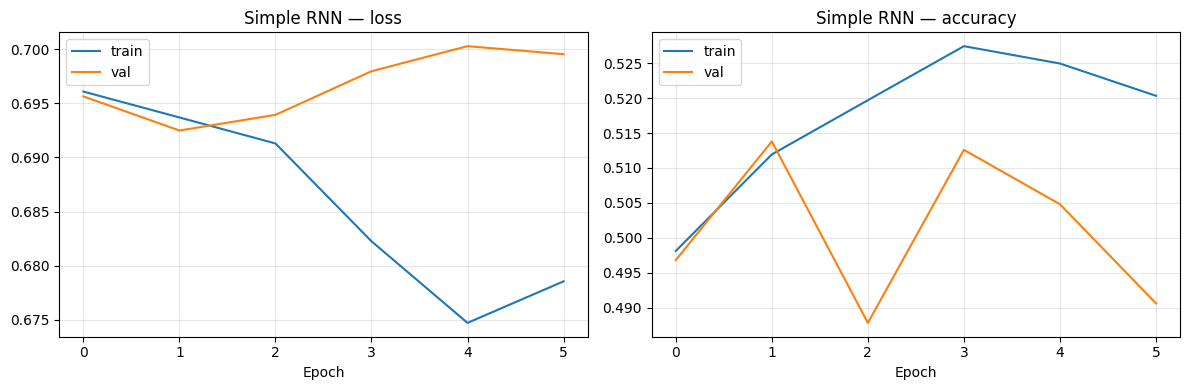

In [ ]:
# Run full evaluation + diagnostics on Simple RNN model

acc_rnn = model_diagnosis(
    model_rnn,
    history_rnn,
    X_test_pad,
    y_test,
    model_name="Simple RNN"
)

In [ ]:
# Train LSTM model with checkpointing and early stopping

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_lstm = ModelCheckpoint(
    "lstm_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoint_lstm, early_stop]
)

Epoch 1/10
1091/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5012 - loss: 0.6934
Epoch 1: val_loss improved from None to 0.69395, saving model to lstm_best_model.keras

Epoch 1: finished saving model to lstm_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 19s 15ms/step - accuracy: 0.5025 - loss: 0.6932 - val_accuracy: 0.4958 - val_loss: 0.6939
Epoch 2/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5193 - loss: 0.6836
Epoch 2: val_loss did not improve from 0.69395
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 14ms/step - accuracy: 0.5178 - loss: 0.6820 - val_accuracy: 0.5006 - val_loss: 0.6969
Epoch 3/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5865 - loss: 0.6477
Epoch 3: val_loss improved from 0.69395 to 0.60707, saving model to lstm_best_model.keras

Epoch 3: finished saving model to lstm_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.6611 - loss: 0.6047 - val_accuracy: 0.7148 - val_loss: 0.6071
Epoch 4/10
1093/1094 ━━━━━━━━━━━

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
DIAGNOSIS: LSTM
 Prediction score stats 
  min : 0.0071
  max : 0.9988
  mean: 0.5495
  std : 0.4194

 Threshold sweep 
  Threshold    Pred Pos%    Pred Neg%   
  0.3          58.8         41.2        
  0.4          57.0         43.0        
  0.5          55.2         44.8        
  0.6          53.3         46.7        
  0.7          51.2         48.8        

Accuracy: 0.8632

 Classification report 
              precision    recall  f1-score   support

    Negative       0.90      0.81      0.86      4961
    Positive       0.83      0.91      0.87      5039

    accuracy                           0.86     10000
   macro avg       0.87      0.86      0.86     10000
weighted avg       0.87      0.86      0.86     10000

 Confusion matrix 
            Pred Neg   Pred Pos
True Neg     4036        925
True Pos     443         4596


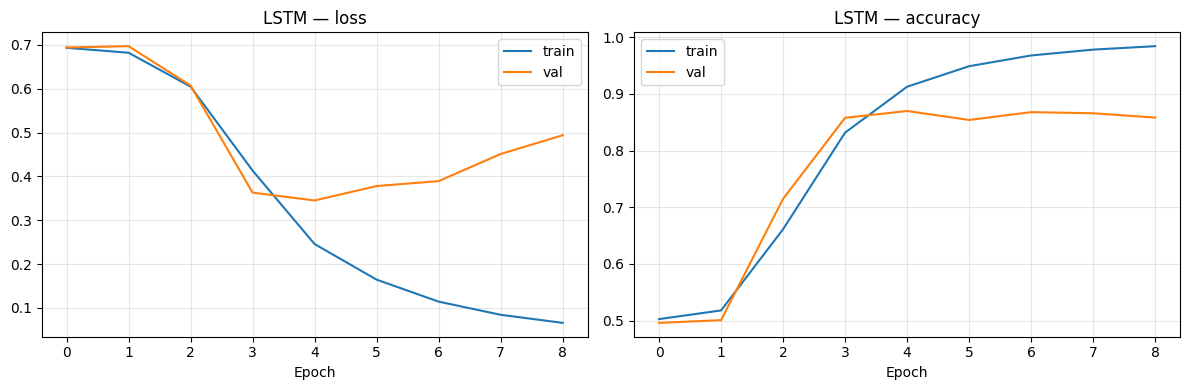

In [ ]:
# Run full evaluation + diagnostics on LSTM model

acc_lstm = model_diagnosis(
    model_lstm,
    history_lstm,
    X_test_pad,
    y_test,
    model_name="LSTM"
)

In [ ]:
!pip install gensim -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 98.3 MB/s eta 0:00:00


In [ ]:
# Load pretrained GloVe embeddings for embedding layer initialization

import gensim.downloader as api

print("Loading pretrained word embeddings (GloVe)...")

word2vec_model = api.load("glove-wiki-gigaword-100")

print(f"Loaded embeddings successfully. Vocabulary size: {len(word2vec_model)}")

Loading pretrained embeddings...
[==================================================] 100.0% 128.1/128.1MB downloaded
Loaded! 400000 words available


In [ ]:
# Build embedding matrix using pretrained GloVe vectors + random init for missing words

import numpy as np
import gc

embedding_dim_w2v = 100  # matches glove-wiki-gigaword-100

embedding_matrix = np.zeros((vocab_size, embedding_dim_w2v))

hit, miss = 0, 0

for word, idx in tokenizer.word_index.items():
    if idx >= vocab_size:
        continue

    if word in word2vec_model:
        embedding_matrix[idx] = word2vec_model[word]
        hit += 1
    else:
        embedding_matrix[idx] = np.random.normal(
            scale=0.6,
            size=(embedding_dim_w2v,)
        )
        miss += 1

print("Embedding coverage:")
print(f"Found words   : {hit}")
print(f"Missing words : {miss}")
print(f"Embedding matrix shape: {embedding_matrix.shape}")

# Free memory after building matrix
del word2vec_model
gc.collect()

print("Pretrained embeddings removed from memory")

Found:   60036 words
Missing: 62349 words
Matrix shape: (122386, 100)
word2vec freed from RAM


In [ ]:
# Build LSTM model using pretrained GloVe embeddings (frozen embedding layer)

print("Model: LSTM with pretrained embeddings (GloVe)")

model_lstm_w2v = Sequential([
    Input(shape=(max_len,)),
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim_w2v,
        weights=[embedding_matrix],
        trainable=False
    ),
    LSTM(hidden_units),
    Dense(1, activation="sigmoid")
])

model_lstm_w2v.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model_lstm_w2v.summary()

MODEL 3: LSTM with pretrained Word2Vec embeddings


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ (None, 302, 100)       │    12,238,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        42,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,280,905 (46.85 MB)

 Trainable params: 12,280,905 (46.85 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Train LSTM model with pretrained embeddings (GloVe) + early stopping + checkpointing

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

checkpoint_w2v = ModelCheckpoint(
    "lstm_w2v_best_model.keras",
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=4,
    restore_best_weights=True,
    verbose=1
)

history_lstm_w2v = model_lstm_w2v.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=10,
    batch_size=32,
    callbacks=[checkpoint_w2v, early_stop]
)

Epoch 1/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5129 - loss: 0.6921
Epoch 1: val_loss improved from None to 0.69092, saving model to lstm_w2v_best_model.keras

Epoch 1: finished saving model to lstm_w2v_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - accuracy: 0.5115 - loss: 0.6921 - val_accuracy: 0.5040 - val_loss: 0.6909
Epoch 2/10
1091/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5074 - loss: 0.6937
Epoch 2: val_loss did not improve from 0.69092
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 15s 14ms/step - accuracy: 0.5083 - loss: 0.6927 - val_accuracy: 0.5144 - val_loss: 0.6920
Epoch 3/10
1093/1094 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5346 - loss: 0.6771
Epoch 3: val_loss improved from 0.69092 to 0.58726, saving model to lstm_w2v_best_model.keras

Epoch 3: finished saving model to lstm_w2v_best_model.keras
1094/1094 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.5883 - loss: 0.6466 - val_accuracy: 0.7312 - val_loss: 0.5873
Epoch 4/10
1093/

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step
DIAGNOSIS: LSTM + Word2Vec
 Prediction score stats 
  min : 0.0035
  max : 0.9944
  mean: 0.4971
  std : 0.4205

 Threshold sweep 
  Threshold    Pred Pos%    Pred Neg%   
  0.3          54.9         45.1        
  0.4          52.4         47.6        
  0.5          49.8         50.2        
  0.6          47.1         52.9        
  0.7          44.3         55.7        

Accuracy: 0.8855

 Classification report 
              precision    recall  f1-score   support

    Negative       0.88      0.89      0.89      4961
    Positive       0.89      0.88      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000

 Confusion matrix 
            Pred Neg   Pred Pos
True Neg     4419        542
True Pos     603         4436


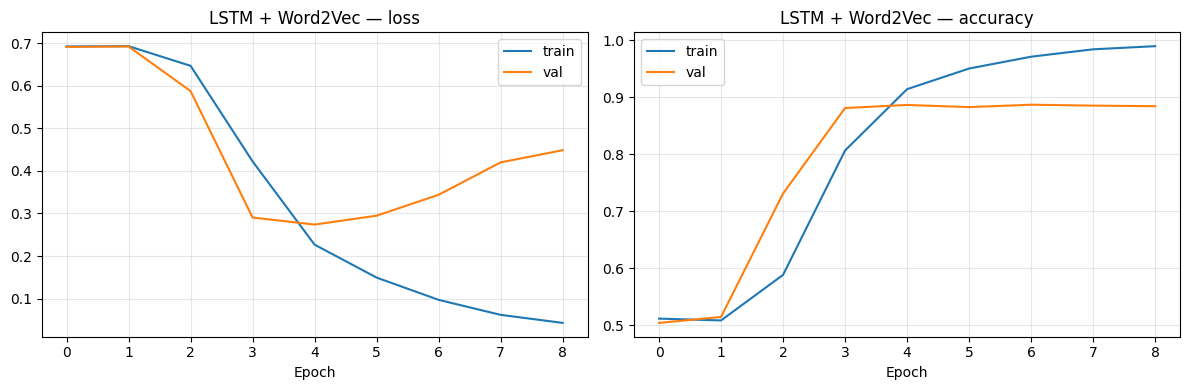

In [ ]:
# Evaluate LSTM model with pretrained embeddings using full diagnosis pipeline

acc_w2v = model_diagnosis(
    model_lstm_w2v,
    history_lstm_w2v,
    X_test_pad,
    y_test,
    model_name="LSTM + Word2Vec"
)

FINAL MODEL COMPARISON
          Model Accuracy
     Simple RNN   0.5147
           LSTM   0.8632
LSTM + Word2Vec   0.8855


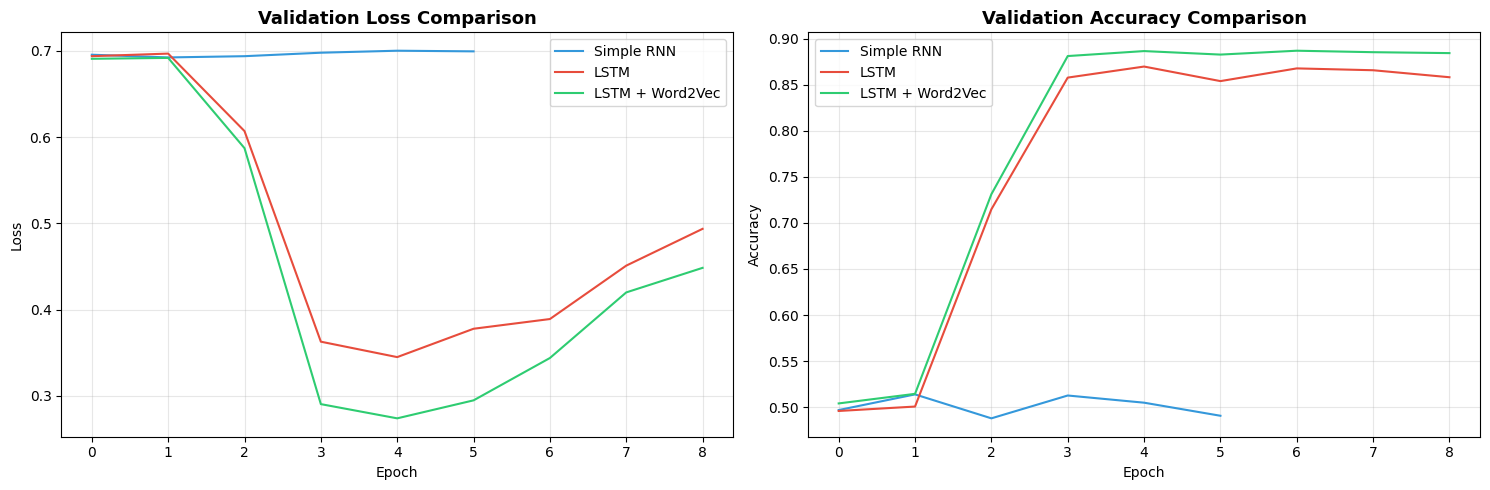

In [ ]:
# Compare performance of Simple RNN, LSTM, and LSTM with pretrained embeddings

import pandas as pd
import matplotlib.pyplot as plt

comparison_df = pd.DataFrame({
    "Model": ["Simple RNN", "LSTM", "LSTM + Word2Vec"],
    "Accuracy": [f"{acc_rnn:.4f}", f"{acc_lstm:.4f}", f"{acc_w2v:.4f}"]
})

print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)
print(comparison_df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history_rnn.history["val_loss"], label="Simple RNN", color="#1f77b4")
axes[0].plot(history_lstm.history["val_loss"], label="LSTM", color="#d62728")
axes[0].plot(history_lstm_w2v.history["val_loss"], label="LSTM + Word2Vec", color="#2ca02c")
axes[0].set_title("Validation Loss Comparison")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_rnn.history["val_accuracy"], label="Simple RNN", color="#1f77b4")
axes[1].plot(history_lstm.history["val_accuracy"], label="LSTM", color="#d62728")
axes[1].plot(history_lstm_w2v.history["val_accuracy"], label="LSTM + Word2Vec", color="#2ca02c")
axes[1].set_title("Validation Accuracy Comparison")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# Error analysis using best model (LSTM + pretrained embeddings)

y_pred_proba = model_lstm_w2v.predict(X_test_pad, verbose=0)
y_pred = (y_pred_proba > 0.5).astype("int32").flatten()

misclassified_indices = np.where(y_pred != y_test)[0]

print(f"Misclassified samples: {len(misclassified_indices)} / {len(y_test)}")

print("\nMisclassification analysis (sample cases):")

for i, idx in enumerate(misclassified_indices[:3]):
    true_label = "Positive" if y_test[idx] == 1 else "Negative"
    pred_label = "Positive" if y_pred[idx] == 1 else "Negative"
    confidence = float(y_pred_proba[idx][0])

    print(f"\nCase {i+1}")
    print(f"True label : {true_label}")
    print(f"Predicted  : {pred_label} (confidence {confidence:.4f})")

    print("\nOriginal review:")
    print(test_df["review"].iloc[idx][:300])

    print("\nCleaned review:")
    print(test_df["cleaned_text"].iloc[idx][:300])

Total misclassified: 1145 out of 10000

MISCLASSIFIED EXAMPLES — Error Analysis

--- Example 1 ---
True Label : Positive
Predicted  : Negative (confidence: 0.0359)
Original Review:
  I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok 
Cleaned Review:
  really liked summerslam due look arena curtain look overall interesting reason anyways could one best summerslams ever wwf lex luger main event yokozuna time ok huge fat man v strong man glad time changed terrible main event like every match luger terrible match card razor ramon v ted dibiase steine

--- Example 2 ---
True Label : Positive
Predicted  : Negative (confidence: 0.1034)
Original Review:
  Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like s

In [ ]:
# Predict sentiment for custom input reviews using trained model

def predict_sentiment(text, model):
    cleaned_text = preprocess_text(text)

    seq = tokenizer.texts_to_sequences([cleaned_text])
    padded = pad_sequences(seq, maxlen=max_len, padding="post", truncating="post")

    prob = model.predict(padded, verbose=0)[0][0]

    if prob > 0.5:
        return "Positive", float(prob)
    else:
        return "Negative", float(1 - prob)

# Sample inference tests
test_reviews = [
    "This movie was absolutely amazing! Great acting and storyline.",
    "Worst film I have ever seen. Total waste of time.",
    "It was okay, nothing special but not terrible either."
]

print("Sample Predictions (LSTM + Word2Vec):\n")

for review in test_reviews:
    sentiment, confidence = predict_sentiment(review, model_lstm_w2v)

    print(f"Review: {review[:80]}")
    print(f"Prediction: {sentiment} (confidence: {confidence:.4f})\n")

Sample Predictions (using LSTM + Word2Vec):

Review: This movie was absolutely amazing! Great acting and storyline.
  → Positive (confidence: 0.9506)

Review: Worst film I have ever seen. Total waste of time.
  → Negative (confidence: 0.9775)

Review: It was okay, nothing special but not terrible either.
  → Negative (confidence: 0.9755)

